In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import maps

# discretize functionality
from discretize import TensorMesh, TreeMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import tarfile

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

save_output = False  # Optional, (No Idea..)

## Sythetic Data and Model First
#### Topo First

In [44]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-200, 200, 41), np.linspace(-200, 200, 41))
rng = np.random.default_rng(seed=737)
z_topo = (
    15 * np.exp(-(x_topo**2 + y_topo**2) / 80**2)
    + 100.0
    + rng.uniform(low=0.0, high=0.5, size=x_topo.shape)
)

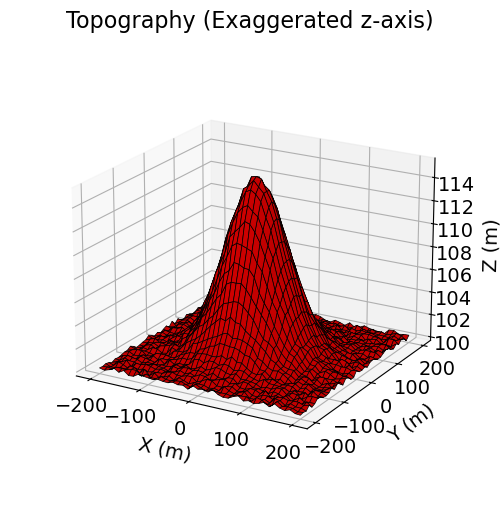

In [45]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
# ax.set_zlim([z_topo.max() - 40, z_topo.max()])
ax.plot_surface(x_topo, y_topo, z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

In [46]:
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo]

#### Define Observation locations

In [47]:
#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x = np.linspace(-80.0, 80.0, 17)
y = np.linspace(-80.0, 80.0, 17)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y])  # Ground Survey
receiver_locations = np.c_[x, y, z+5] #Add 1 m to avoid tree mesh blowing up 


In [48]:
# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components) #List of receivers from locations
receiver_list = [receiver_list]

# Define the inducing field
inclination = 90  # inclination [deg]
declination = 0  # declination [deg]
amplitude = 50000  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

#### Design Tensor (Mesh)

In [49]:
# The mesh is divifing up our model into many small cells, each with their own susceptibility value.
# Generate tensor mesh with top at z = 0 m
dh = 5.0 #Cell width of 5m
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)] #Added 40m of padding 
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
tensor_mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
tensor_mesh.origin += np.r_[0.0, 0.0, z_topo.max()]

#### Define Active cells

In [50]:
#By active cells, we mean the cells that are below the topography. Air cells should not have a suceptibility value.
# Indices of the active mesh cells from topography (e.g. cells below surface), boolenans
active_cells = active_from_xyz(tensor_mesh, topo_xyz) #simpeg function

#### Mapping Active Cells

In [51]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map

#### Define the Model

In [52]:
# Weakly susceptible background, strognly susceptible sphere (to start)

# Define susceptibility values for each unit in SI
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

# Instantiate a vector array. Models in SimPEG are vector arrays.
model = background_susceptibility * np.ones(n_active)

# You can use SimPEG utilities to add structures to the model more concisely,
# or index the mesh cells manually.
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, tensor_mesh.cell_centers
)
ind_sphere = ind_sphere[active_cells]
model[ind_sphere] = sphere_susceptibility

In [53]:
# Mapping to ignore inactive cells when plotting model
plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

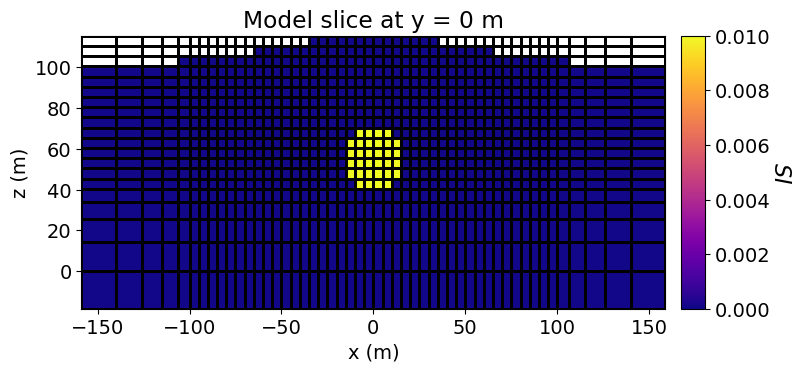

In [54]:
# Plot Susceptibility Model
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
tensor_mesh.plot_slice(
    plotting_map * model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

#### Define forward simulation

In [55]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

#### Simulate total environemnt data

In [56]:
dobs = simulation.dpred(model) #get predicted data from model

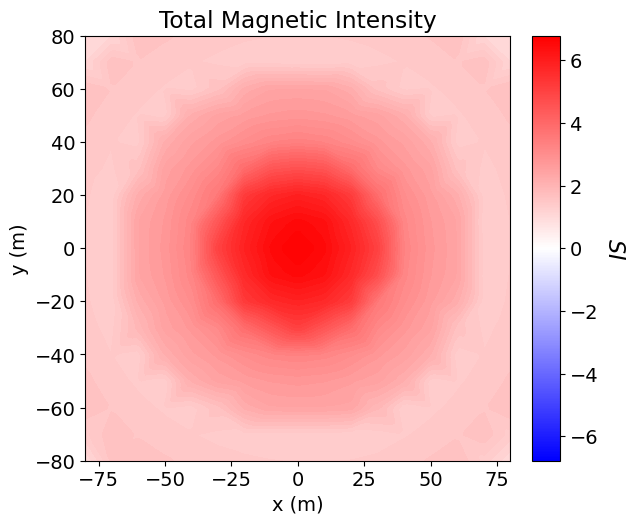

In [57]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dobs)), vmax=np.max(np.abs(dobs)))
plot2Ddata(
    receiver_list[0].locations,
    dobs,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()


## Now invert data 

In [58]:
#We already have:

#The survey --> survey
#The data --> dobs
#The topography --> topo_xyz
#Receiver locations --> receiver_locations
#The mesh --> mesh
#active cells --> active_cells
#Mapping acitve cells --> model_map
#Forward operator --> simulation

#Assign Uncertainties
maximum_anomaly = np.max(np.abs(dobs))
floor_uncertainty = 0.02 * maximum_anomaly
uncertainties = floor_uncertainty * np.ones(np.shape(dobs))
print("Floor uncertainty: {}".format(floor_uncertainty))

#Create data object
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

Floor uncertainty: 0.13560849249612622


### Starting and reference models

In [59]:
starting_tensor_model = 1e-6 * np.ones(n_active)
reference_tensor_model = np.zeros_like(starting_tensor_model)

# Mapping to ignore inactive cells when plotting
tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

### Define Data Misfit

In [60]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit_tensor = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

### Define the Regularization

In [61]:
#Using weighted least squares regularization to costrain the rgularization result
regularization_tensor = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_cells,
    length_scale_x=1.0,
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=False,
)

### Define Optimization Algorithm

In [62]:
optimization_tensor = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

### Define the inverse problem

In [63]:
# Full inverse problem definition needs daata misfit, regularization, and optimization objects
inverse_problem_L2 = inverse_problem.BaseInvProblem(data_misfit_tensor, regularization_tensor, optimization_tensor)

### Provide Inversion Directives

In [64]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

## Define and Run Inversion

In [65]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inverse_problem_L2, directives_list)

# Run inversion
recovered_tensor_model = inv_L2.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 289.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.48e+07  1.20e+05  1.68e-07  1.20e+05                         0           inf          inf                
   1  1.48e+07  8.65e+03  7.21e-04  1.93e+04    1.28e+07      0      10       1.70e-01     2.26e+06              
   2  7.41e+06  8.00e+02  1.00e-03  8.21e+03    3.54e+06      0      8        7.47e-03     2.58e+04              
   3  3.70e+06  2.97e+02  1.08e-03  4.31e+03    6.32e+05      0      10       1.06e-02     6.88e+03              
   4  1.85e+06  9.92e+01  1.15e-03  2.23e+03    3.80e+05      0      10       1.72e-02     6.60e+03              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 7.0474e+01 <=

## Plot Data Misfit

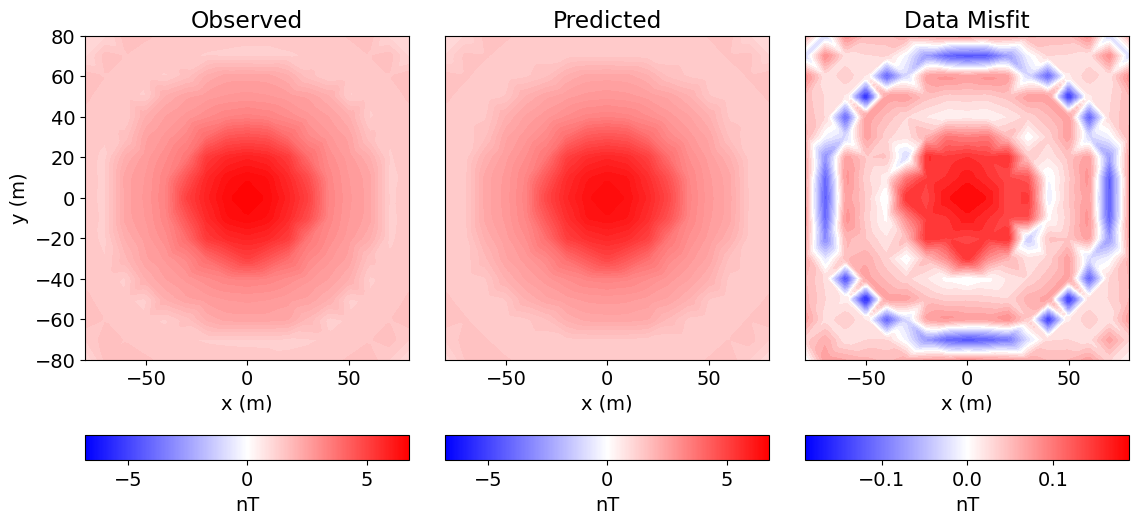

In [66]:
# Predicted data with final recovered model.
dpred_inverse = inverse_problem_L2.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_inverse, (dobs - dpred_inverse)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_inverse))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

The data misfit is full of structure...

### Plot recovered model

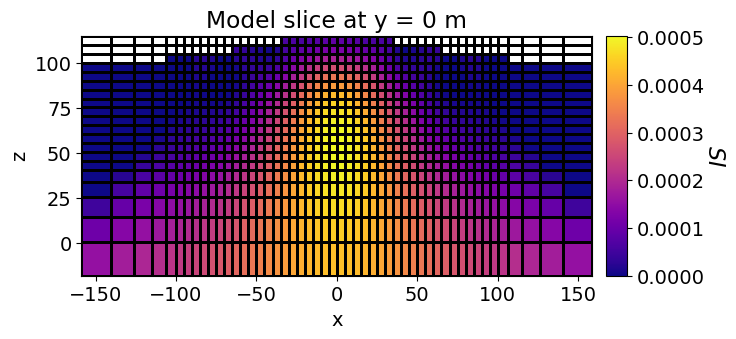

In [67]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_tensor_model), vmax=np.max(recovered_tensor_model)
)
tensor_mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

## Iteratively Re-Weighted Least Squares Inversion
- uses a tree mesh (or doesnt have to)

### Do NOT Reassign the uncertainties

SimPEG example logic:
decrease uncertainties of locations with largest misfit --> model that better fits the anomalies
Force the model to fit the uncertain regions

In Our case:
Structured misfit - so we would be forcing a fit to our misfit structures
--> use same uncertainties as before


In [68]:
# # Compute normalized data misfits
# normalized_data_misfits = (dobs - dpred_inverse) / uncertainties

In [69]:
# # Plot the normalized data misfits
# fig = plt.figure(figsize=(6, 3))
# ax = fig.add_subplot(111)
# ax.plot(np.sort(normalized_data_misfits))
# ax.set_title("Normalized Data Misfits (sorted)")
# ax.grid()
# plt.show(fig)

In [70]:
# # Generate new uncertainties
# new_uncertainties = uncertainties.copy()
# new_uncertainties[np.abs(normalized_data_misfits) > 2.0] /= 2.5

# # Generate new data object
# new_data_object = data.Data(survey, dobs=dobs, standard_deviation=new_uncertainties)

### Design a tree mesh

##### Can use the tensor mesh too


In [71]:
# dx = 5  # minimum cell width (base tree_mesh cell width) in x
# dy = 5  # minimum cell width (base tree_mesh cell width) in y
# dz = 5  # minimum cell width (base tree_mesh cell width) in z

# x_length = 240.0  # domain width in x
# y_length = 240.0  # domain width in y
# z_length = 120.0  # domain width in z

# # Compute number of base tree_mesh cells required in x and y
# nbcx = 2 ** int(np.round(np.log(x_length / dx) / np.log(2.0)))
# nbcy = 2 ** int(np.round(np.log(y_length / dy) / np.log(2.0)))
# nbcz = 2 ** int(np.round(np.log(z_length / dz) / np.log(2.0)))

# # Define the base tree_mesh
# hx = [(dx, nbcx)]
# hy = [(dy, nbcy)]
# hz = [(dz, nbcz)]
# tree_mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# # Shift vertically to top same as maximum topography
# tree_mesh.origin += np.r_[0.0, 0.0, topo_xyz[:, -1].max()]

# # Refine based on surface topography
# tree_mesh.refine_surface(topo_xyz, padding_cells_by_level=[2, 2], finalize=False)

# # Refine box based on region of interest
# wsb_corner = np.c_[-100, -100, 20]
# ent_corner = np.c_[100, 100, 100]
# # Note -1 is a flag for smallest cell size
# tree_mesh.refine_box(wsb_corner, ent_corner, levels=[-1], finalize=False)

# tree_mesh.finalize()

### Define Active Cells
For tree mesh

In [72]:
# ind_tree_active = active_from_xyz(tree_mesh, topo_xyz)
# n_tree_active = int(ind_tree_active.sum())

### Mapping from model to active cells
for tree mesh

In [73]:
# tree_model_map = maps.IdentityMap(nP=n_active)

### Starting and References models
for tree mesh

In [74]:
# starting_tree_model = 1e-6 * np.ones(n_tree_active)
# reference_tree_model = np.zeros_like(starting_tree_model)

### Define forward simulation

In [75]:
# # Same as before, but with tree mesh

# simulation_irls = magnetics.simulation.Simulation3DIntegral(
#     survey=survey,
#     mesh=tree_mesh,
#     model_type="scalar",
#     chiMap=model_map,
#     active_cells=ind_tree_active,
#     engine="choclo",
# )


### Define Data Misfit

In [76]:
# # Same as before, but for tree mesh

# data_misfit_irls = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_irls)


### Define the regularization

In [77]:
# # regularization for tree mesh

# regularization_irls_tree = regularization.Sparse(
#     tree_mesh,
#     active_cells=ind_tree_active,
#     alpha_s=dh**-2,
#     alpha_x=1,
#     alpha_y=1,
#     alpha_z=1,
#     reference_model=reference_tree_model,
#     reference_model_in_smooth=False,
#     norms=[0, 1, 1, 1],
# )

#Using weighted least squares regularization to costrain the rgularization result
regularization_irls_tensor = regularization.Sparse(
    tensor_mesh,
    active_cells=active_cells,
    alpha_s=dh**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

### Define tbe optimization algorithm

In [78]:
# Same as L2 case
optimization_irls = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)


### Define the inverse problem

In [79]:
inv_prob_irls = inverse_problem.BaseInvProblem(data_misfit_tensor, regularization_irls_tensor, optimization_tensor)

### Provide inversion directives

In [80]:
sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    f_min_change=1e-4,
    max_irls_iterations=25,
    chifact_start=1.0,
)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
]


### Define and run the inversion

In [81]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_tree_model = inv_irls.run(starting_tensor_model)

The callback on the ProjectedGNCG minimizer was replaced.

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  3.87e+08  1.20e+05  6.72e-09  1.20e+05                         10       1.72e-02     6.60e+03              
   1  3.87e+08  8.33e+03  2.65e-05  1.86e+04    1.28e+07      0      6        9.66e-03     1.28e+05              
   2  1.93e+08  8.79e+02  3.94e-05  8.50e+03    2.83e+06      0      7        6.90e-03     1.87e+04              
   3  9.67e+07  3.27e+02  4.30e-05  4.49e+03    6.68e+05      0      9        9.73e-03     6.96e+03              
   4  4.84e+07  1.07e+02  4.59e-05  2.33e+03    4.05e+05      0      10       1.59e-02     6.47e+03     

For the inversion to run, we had to make the receiver locations 3m above the topography. Why? (still working on it)

### Plot the data misfit

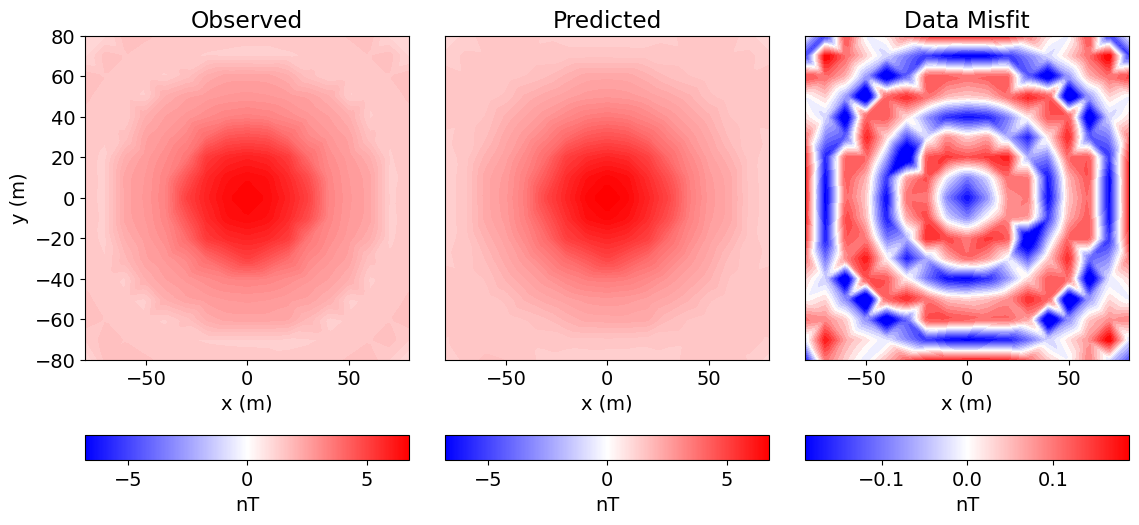

In [82]:
# Predicted data with final recovered model.
dpred_irls = inv_prob_irls.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_irls, (dobs - dpred_irls)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_inverse))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

### Plot all the models

In [83]:
# Recreate True Model on a Tensor Mesh
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

true_model = background_susceptibility * np.ones(n_active)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, tensor_mesh.cell_centers[active_cells]
)
true_model[ind_sphere] = sphere_susceptibility

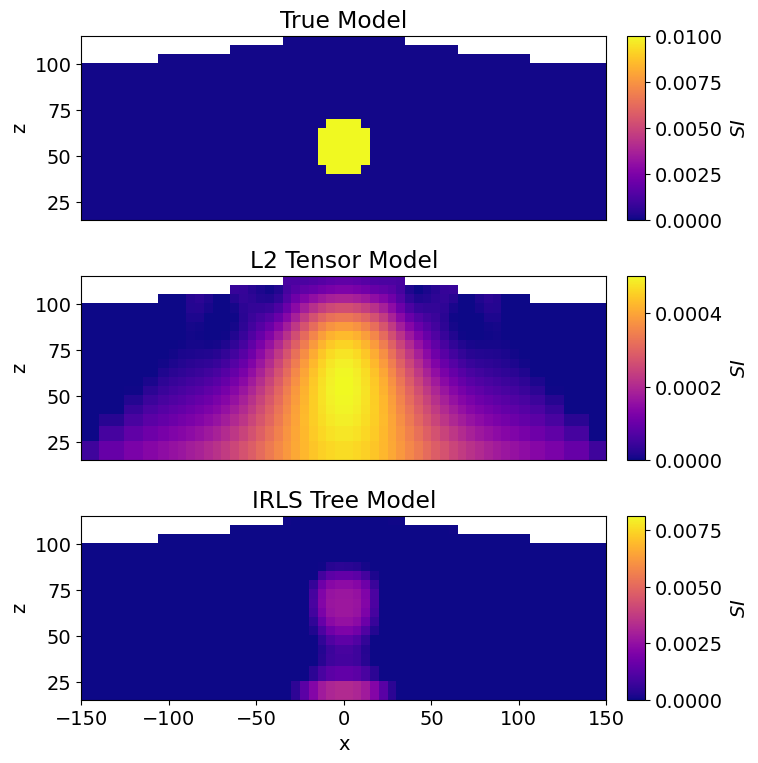

In [84]:
# mesh_list_tree = [tensor_mesh, tensor_mesh, tree_mesh]
# ind_list_tree = [active_cells, active_cells, ind_tree_active]
mesh_list = [tensor_mesh, tensor_mesh, tensor_mesh]
ind_list = [active_cells, active_cells, active_cells]
model_list = [true_model, recovered_tensor_model, recovered_tree_model]
title_list = ["True Model", "L2 Tensor Model", "IRLS Tree Model"]
cplot = 3 * [None]
cbar = 3 * [None]
norm = 3 * [None]

fig = plt.figure(figsize=(7, 8))
ax1 = [fig.add_axes([0.1, 0.7 - 0.3 * ii, 0.75, 0.23]) for ii in range(0, 3)]
ax2 = [fig.add_axes([0.88, 0.7 - 0.3 * ii, 0.025, 0.23]) for ii in range(0, 3)]

for ii, mesh in enumerate(mesh_list):
    plotting_map = maps.InjectActiveCells(mesh, ind_list[ii], np.nan)
    max_abs = np.max(np.abs(model_list[ii]))
    norm[ii] = mpl.colors.Normalize(vmin=0.0, vmax=max_abs)

    cplot[ii] = mesh.plot_slice(
        plotting_map * model_list[ii],
        normal="Y",
        ax=ax1[ii],
        ind=int(mesh.shape_cells[1] / 2),
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm[ii]},
    )
    ax1[ii].set_xlim([-150, 150])
    ax1[ii].set_ylim([topo_xyz[:, -1].max() - 100, topo_xyz[:, -1].max()])
    if ii < 2:
        ax1[ii].set_xlabel("")
        ax1[ii].set_xticks([])
    ax1[ii].set_title(title_list[ii])

    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar[ii].set_label("$SI$", labelpad=5)